In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

## CNN6

### Loss и Accuracy

#### Предобучение

In [2]:
f = open("statistics/baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/pc_pretrain.json")
pc_stat = json.load(f)

f = open("statistics/f_cov_pretrain.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

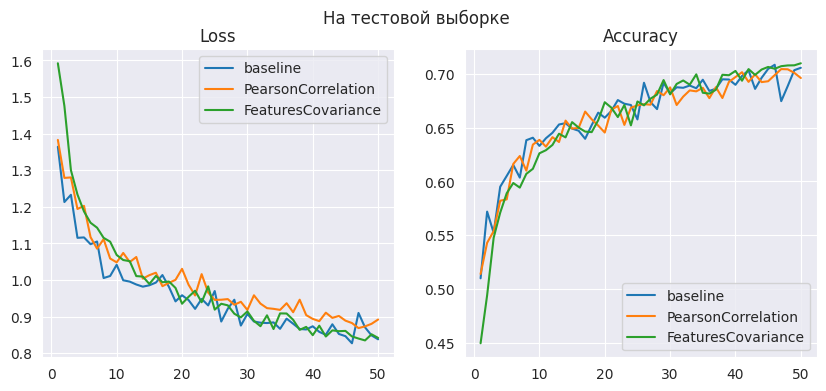

In [4]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].legend()
ax[1].set_title("Accuracy")

fix.suptitle("На тестовой выборке")

#### Дообучение

In [9]:
f = open("statistics/baseline_quant.json")
baseline_stat = json.load(f)

f = open("statistics/pc_quant.json")
pc_stat = json.load(f)

f = open("statistics/f_cov_quant.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

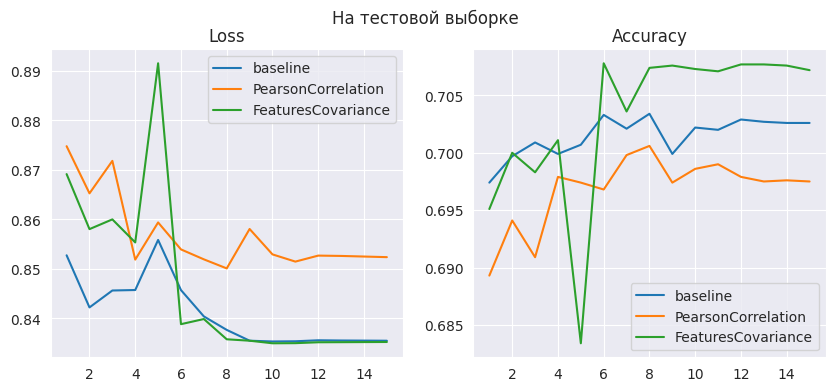

In [10]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].legend()
ax[1].set_title("Accuracy")

fix.suptitle("На тестовой выборке")

### Corrls

#### Предобучение

In [15]:
f = open("statistics/baseline_pretrain_corrls_L.json")
baseline_stat = json.load(f)

f = open("statistics/pc_pretrain_corrls_L.json")
pc_stat = json.load(f)

f = open("statistics/f_cov_pretrain_corrls_L.json")
f_cov_stat = json.load(f)

In [16]:
conv_layers = ["conv0", "conv1", "conv2", "conv3", "fc1"]

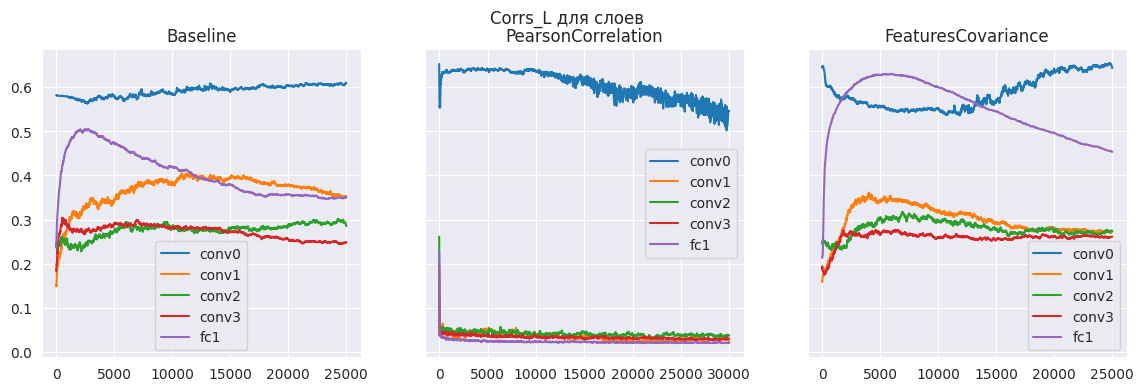

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Corrs_L для слоев")

axs[0].set_title("Baseline")
for i, layer_name in enumerate(conv_layers):
    axs[0].plot(baseline_stat["corrs_l"][i], label=layer_name)
axs[0].legend()

axs[1].set_title("PearsonCorrelation")
for i, layer_name in enumerate(conv_layers):
    axs[1].plot(pc_stat["corrs_l"][i], label=layer_name)
axs[1].legend()

axs[2].set_title("FeaturesCovariance")
for i, layer_name in enumerate(conv_layers):
    axs[2].plot(f_cov_stat["corrs_l"][i], label=layer_name)
axs[2].legend()

print()

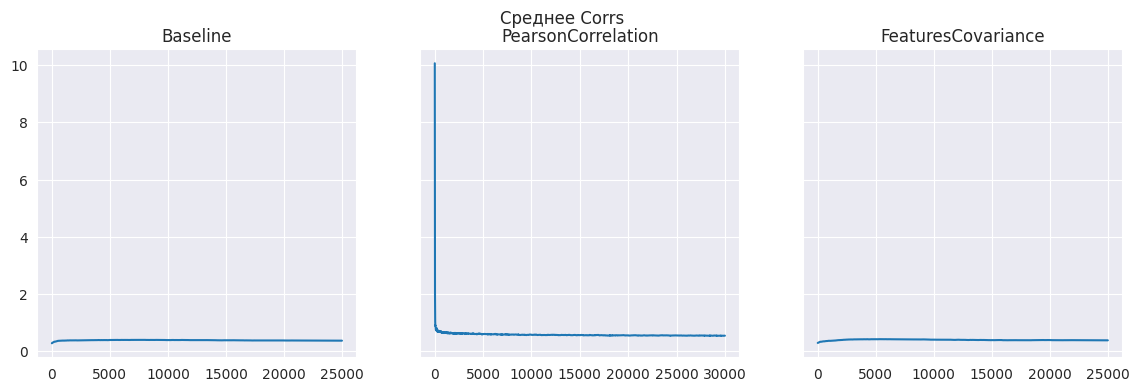

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Среднее Corrs")

axs[0].set_title("Baseline")
axs[0].plot(baseline_stat["mean_corrs"])

axs[1].set_title("PearsonCorrelation")
axs[1].plot(pc_stat["mean_corrs"])

axs[2].set_title("FeaturesCovariance")
axs[2].plot(f_cov_stat["mean_corrs"])

print()

#### Дообучение

In [28]:
f = open("statistics/baseline_quant_corrls_L.json")
baseline_stat = json.load(f)

f = open("statistics/pc_quant_corrls_L.json")
pc_stat = json.load(f)

f = open("statistics/f_cov_quant_corrls_L.json")
f_cov_stat = json.load(f)

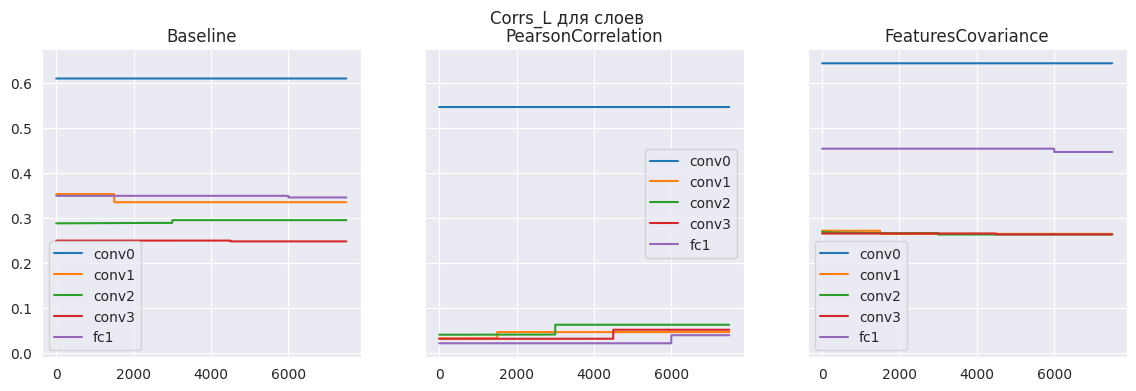

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Corrs_L для слоев")
k = 4
axs[0].set_title("Baseline")
for i, layer_name in enumerate(conv_layers):
    axs[0].plot(baseline_stat["corrs_l"][i], label=layer_name)
# m = max(baseline_stat["corrs_l"][k])
# axs[0].plot(np.array(baseline_stat["corrs_l"][k]) / m)
axs[0].legend()

axs[1].set_title("PearsonCorrelation")
for i, layer_name in enumerate(conv_layers):
    axs[1].plot(pc_stat["corrs_l"][i], label=layer_name)
# m = max(pc_stat["corrs_l"][k])
# axs[1].plot(np.array(pc_stat["corrs_l"][k]) / m)
axs[1].legend()

axs[2].set_title("FeaturesCovariance")
for i, layer_name in enumerate(conv_layers):
    axs[2].plot(f_cov_stat["corrs_l"][i], label=layer_name)
# m = max(f_cov_stat["corrs_l"][k])
# axs[2].plot(np.array(f_cov_stat["corrs_l"][k]) / m)
axs[2].legend()

print()

### Матрицы Пирсона

#### Предобучение

In [39]:
from cifar_models import CNN6
import torch

model_baseline = CNN6()
model_baseline.load_state_dict(torch.load("models/baseline_pretrain.pt", weights_only=True))
model_baseline.eval()

model_pc = CNN6()
model_pc.load_state_dict(torch.load("models/pc_pretrain.pt", weights_only=True))
model_pc.eval()

model_f_cov = CNN6()
model_f_cov.load_state_dict(torch.load("models/f_cov_pretrain.pt", weights_only=True))
model_f_cov.eval()

print()

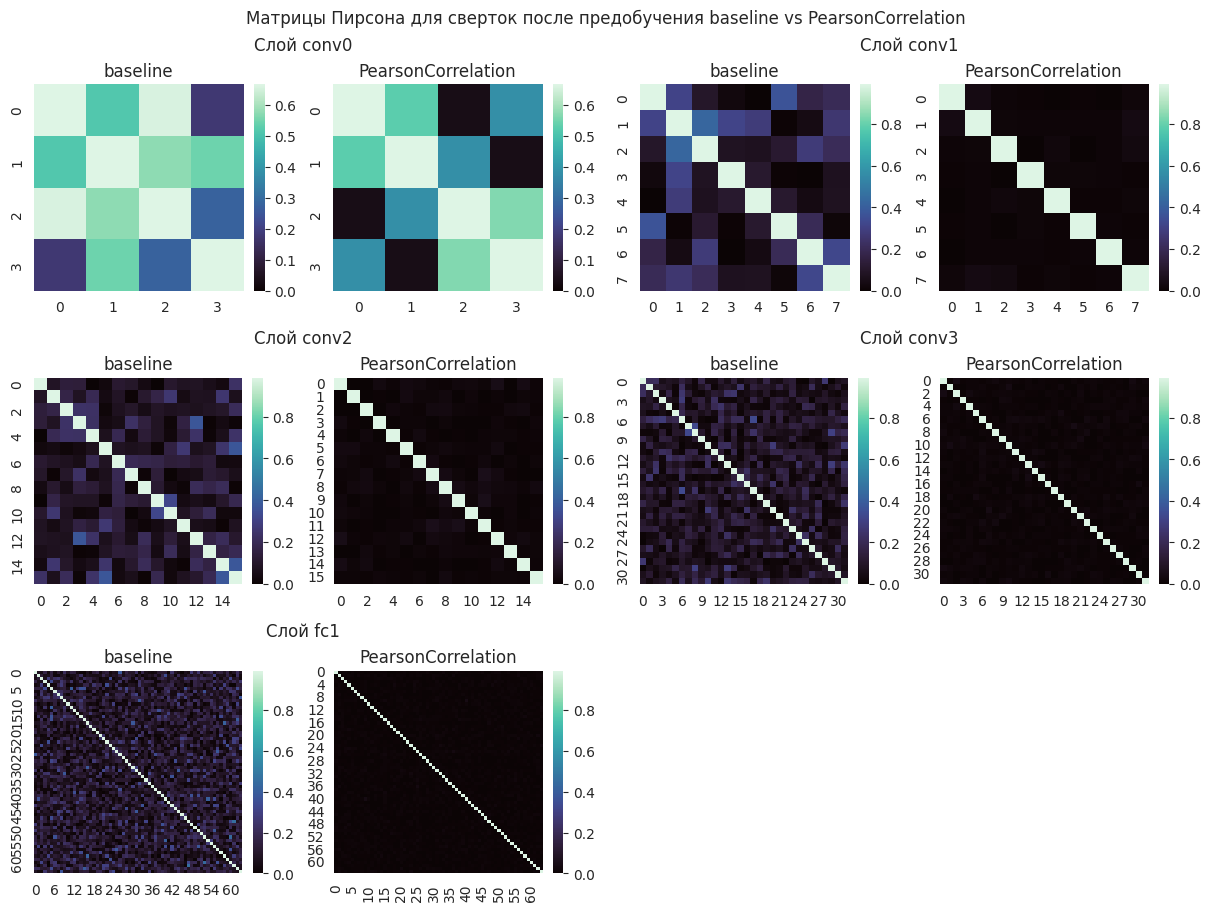

In [40]:
import seaborn as sns
from PearsonCorrelation import pearson_correlation_mat

fig = plt.figure(constrained_layout=True, figsize=(12, 9))
fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs PearsonCorrelation')
subfigs = fig.subfigures(nrows=3, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_pc = pearson_correlation_mat(model_pc.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_pc.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("PearsonCorrelation")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

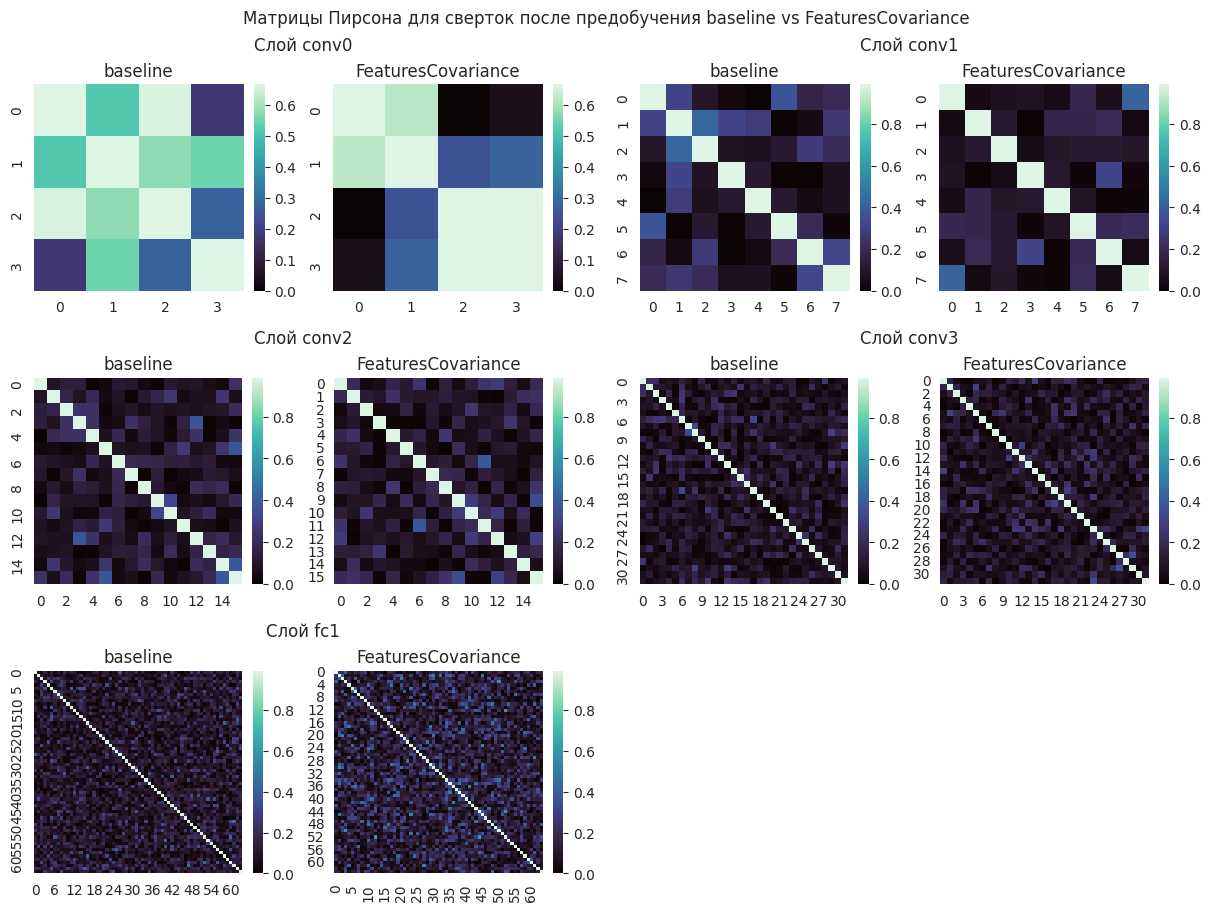

In [41]:
fig = plt.figure(constrained_layout=True, figsize=(12, 9))
fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs FeaturesCovariance')
subfigs = fig.subfigures(nrows=3, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_f_cov = pearson_correlation_mat(model_f_cov.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_f_cov.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("FeaturesCovariance")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

# CNN8

### Loss и Accuracy

#### Предобучение

In [2]:
f = open("statistics/CNN8_baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/CNN8_pc_pretrain.json")
pc_stat = json.load(f)

f = open("statistics/CNN8_f_cov_pretrain.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

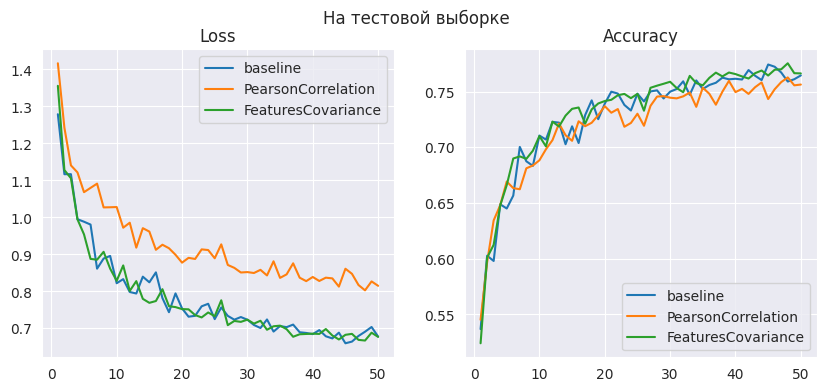

In [3]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].legend()
ax[1].set_title("Accuracy")

fix.suptitle("На тестовой выборке")

#### Дообучение

In [4]:
f = open("statistics/CNN8_baseline_quant.json")
baseline_stat = json.load(f)

f = open("statistics/CNN8_pc_quant.json")
pc_stat = json.load(f)

f = open("statistics/CNN8_f_cov_quant.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

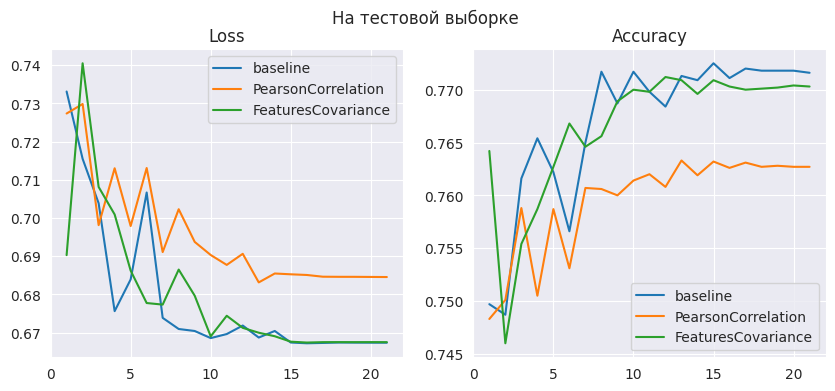

In [5]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].legend()
ax[1].set_title("Accuracy")

fix.suptitle("На тестовой выборке")

### Corrls

#### Предобучение

In [6]:
f = open("statistics/CNN8_baseline_pretrain_corrls_L.json")
baseline_stat = json.load(f)

f = open("statistics/CNN8_pc_pretrain_corrls_L.json")
pc_stat = json.load(f)

f = open("statistics/CNN8_f_cov_pretrain_corrls_L.json")
f_cov_stat = json.load(f)

In [7]:
conv_layers = ["conv0", "conv1_1", "conv1_2", "conv2", "conv3_1", "conv3_2", "fc1"]

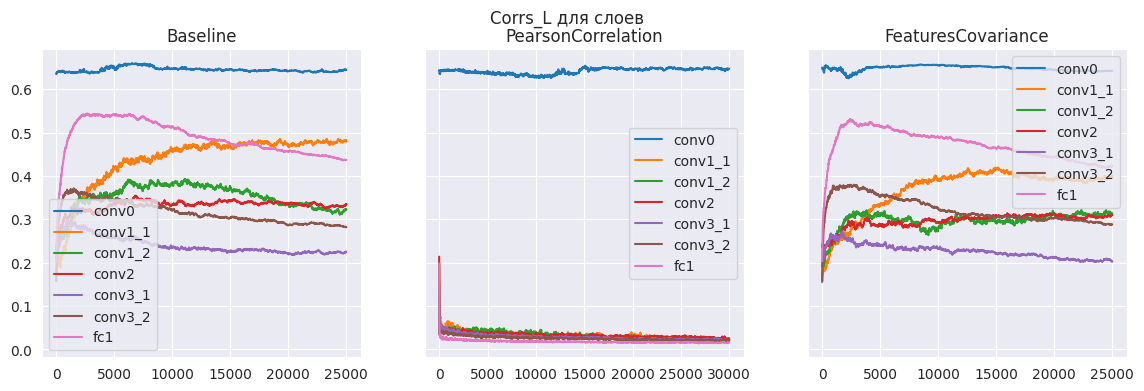

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Corrs_L для слоев")

axs[0].set_title("Baseline")
for i, layer_name in enumerate(conv_layers):
    axs[0].plot(baseline_stat["corrs_l"][i], label=layer_name)
axs[0].legend()

axs[1].set_title("PearsonCorrelation")
for i, layer_name in enumerate(conv_layers):
    axs[1].plot(pc_stat["corrs_l"][i], label=layer_name)
axs[1].legend()

axs[2].set_title("FeaturesCovariance")
for i, layer_name in enumerate(conv_layers):
    axs[2].plot(f_cov_stat["corrs_l"][i], label=layer_name)
axs[2].legend()

print()

In [11]:
print(len(pc_stat["corrs_l"][0]), len(baseline_stat["corrs_l"][0]))

30000 25000


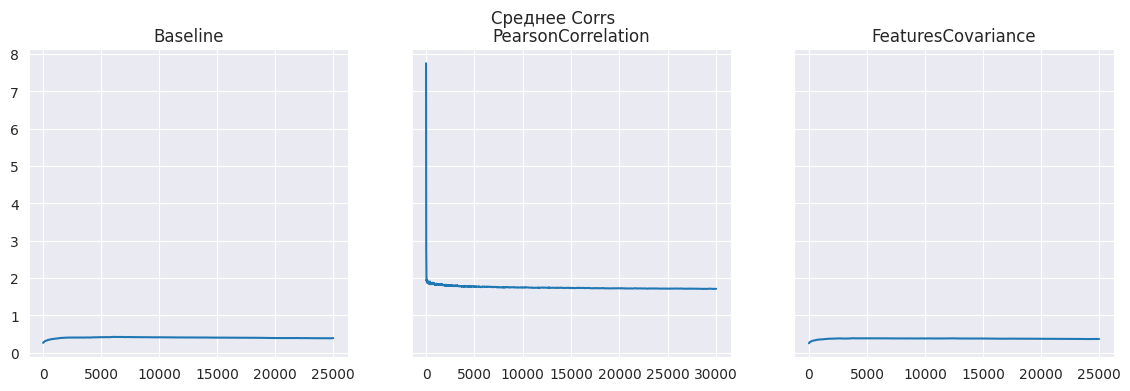

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Среднее Corrs")

axs[0].set_title("Baseline")
axs[0].plot(baseline_stat["mean_corrs"])

axs[1].set_title("PearsonCorrelation")
axs[1].plot(pc_stat["mean_corrs"])

axs[2].set_title("FeaturesCovariance")
axs[2].plot(f_cov_stat["mean_corrs"])

print()

### Матрицы Пирсона

#### Предобучение

In [12]:
from cifar_models import CNN6
import torch

model_baseline = CNN6()
model_baseline.load_state_dict(torch.load("models/baseline_pretrain.pt", weights_only=True))
model_baseline.eval()

model_pc = CNN6()
model_pc.load_state_dict(torch.load("models/pc_pretrain.pt", weights_only=True))
model_pc.eval()

model_f_cov = CNN6()
model_f_cov.load_state_dict(torch.load("models/f_cov_pretrain.pt", weights_only=True))
model_f_cov.eval()

print()

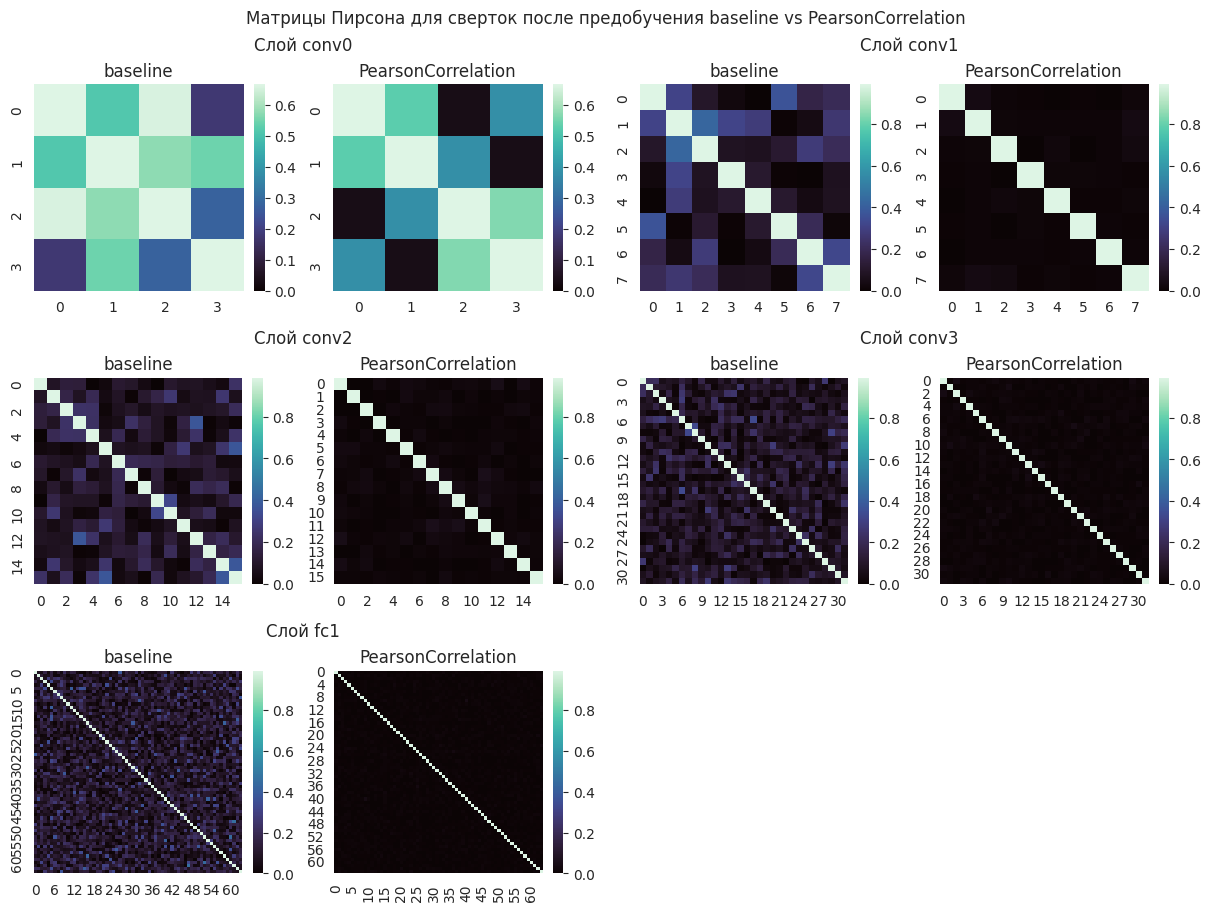

In [13]:
import seaborn as sns
from PearsonCorrelation import pearson_correlation_mat

fig = plt.figure(constrained_layout=True, figsize=(12, 9))
fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs PearsonCorrelation')
subfigs = fig.subfigures(nrows=3, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_pc = pearson_correlation_mat(model_pc.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_pc.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("PearsonCorrelation")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

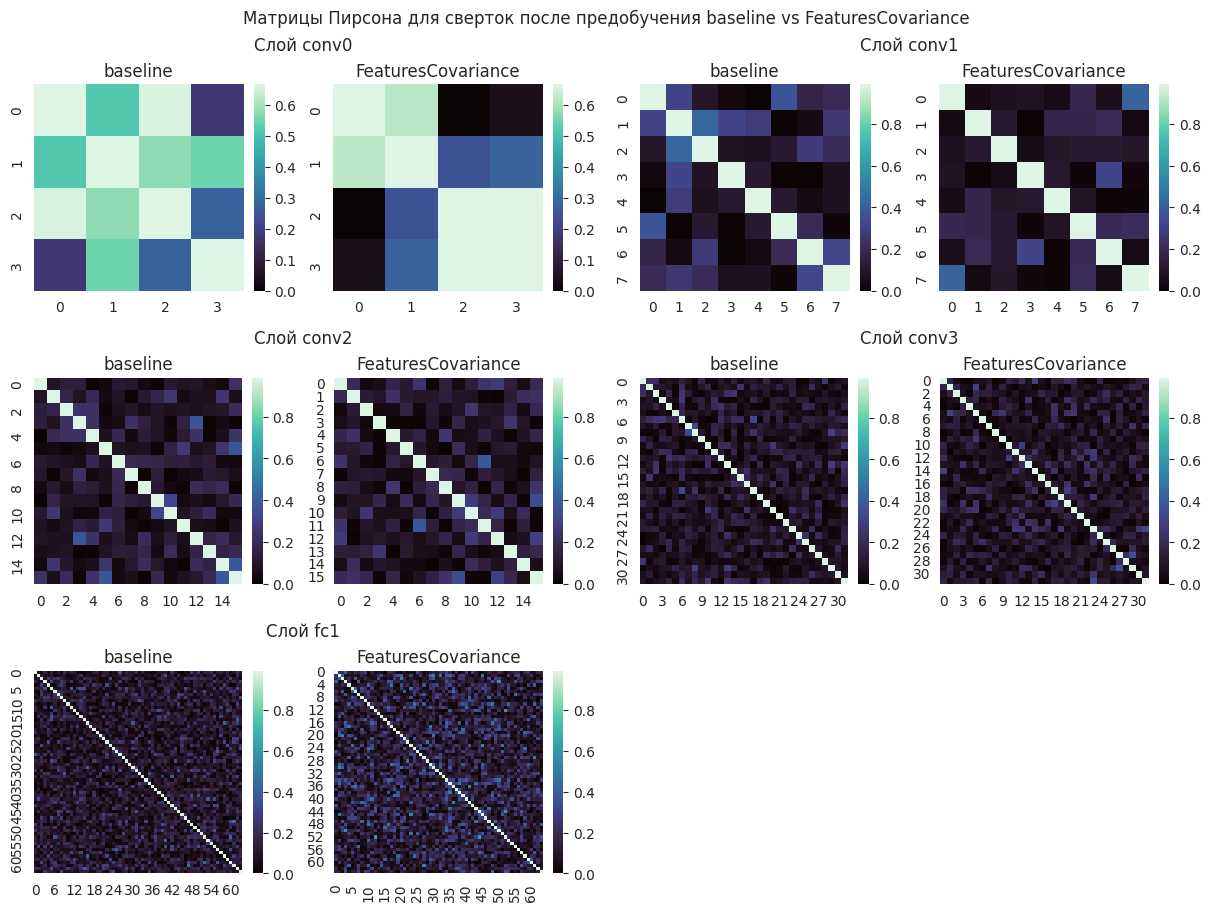

In [14]:
fig = plt.figure(constrained_layout=True, figsize=(12, 9))
fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs FeaturesCovariance')
subfigs = fig.subfigures(nrows=3, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_f_cov = pearson_correlation_mat(model_f_cov.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_f_cov.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("FeaturesCovariance")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

# CNN10

### Loss и Accuracy

#### Предобучение

In [ ]:
f = open("statistics/CNN10_baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/CNN10_pc_pretrain.json")
pc_stat = json.load(f)

f = open("statistics/CNN10_f_cov_pretrain.json")
f_cov_stat = json.load(f)

In [ ]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].legend()
ax[1].set_title("Accuracy")

fix.suptitle("На тестовой выборке")
